# Reviewer-Fixed Submission Notes

This version directly addresses the evaluation feedback for Prateek:

- Validates that the correct **99,441-order** master dataset is loaded, preventing the earlier 30,385-row mismatch.
- Includes an optional reproducible join function to rebuild `master_cleaned.csv` from the original Olist tables.
- Keeps a finished numerical conclusion instead of a template scaffold.
- Improves the main charts with clearer axes, labels, annotations and percentage/currency formatting.

# Olist E-Commerce: Complete EDA and Statistical Analysis

**Dataset:** `master_cleaned.csv`  
**Notebook type:** Google Colab-ready  
**Handbook alignment:** Part A (Statistics, Chapters 1-8) and Part B, Chapter 10 (Olist E-Commerce, pages 13-15).

## Business questions

1. What does one row represent, and is the order-level table safe to analyse?
2. What are the main sales, customer, delivery, and review patterns?
3. Are monetary and delivery variables skewed?
4. Does slower or late delivery relate to poorer reviews?
5. Is the observed difference statistically significant and practically important?
6. Who are the best customers using RFM segmentation?
7. How concentrated is revenue using Pareto analysis?

> **Important:** This is observational business data, not a controlled experiment. Statistical relationships are evidence of association, not proof of causation.

## How to run in Google Colab

1. Upload this notebook to Colab.
2. Run the cells from top to bottom.
3. When the loading cell asks, upload `master_cleaned.csv`.
4. The final section saves the main result tables as CSV files.

In [1]:
# Core libraries available in Google Colab
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

from IPython.display import display
from scipy.stats import spearmanr, mannwhitneyu, chi2_contingency
from statsmodels.stats.proportion import proportion_confint, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

currency_millions = FuncFormatter(lambda value, _: f"R${value / 1_000_000:.1f}M")
whole_number = FuncFormatter(lambda value, _: f"{value:,.0f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## Optional: rebuild the order-level master file from raw Olist tables

The analysis expects one row per order. The function below aggregates one-to-many payment, item and review tables **before** joining, preventing duplicated orders and inflated revenue. It runs only when called.

In [2]:
EXPECTED_ORDER_ROWS = 99_441

RAW_FILE_NAMES = {
    "orders": "olist_orders_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "items": "olist_order_items_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
}

def build_master_cleaned(raw_dir, output_path="master_cleaned.csv"):
    raw_dir = Path(raw_dir)
    paths = {name: raw_dir / filename for name, filename in RAW_FILE_NAMES.items()}
    missing = [str(path) for path in paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Missing raw Olist files:\n- " + "\n- ".join(missing)
        )

    orders = pd.read_csv(paths["orders"])
    customers = pd.read_csv(paths["customers"])
    payments = pd.read_csv(paths["payments"])
    items = pd.read_csv(paths["items"])
    reviews = pd.read_csv(paths["reviews"])

    if not orders["order_id"].is_unique:
        raise ValueError("The raw orders table must contain one row per order_id.")

    payment_agg = (
        payments.groupby("order_id", as_index=False)
        .agg(
            total_payment_value=("payment_value", "sum"),
            payment_installments=("payment_installments", "max"),
            payment_types_used=(
                "payment_type",
                lambda values: ",".join(sorted(set(values.dropna().astype(str)))),
            ),
        )
    )

    item_agg = (
        items.groupby("order_id", as_index=False)
        .agg(
            total_items=("order_item_id", "count"),
            total_freight=("freight_value", "sum"),
            total_price=("price", "sum"),
        )
    )

    review_agg = (
        reviews.groupby("order_id", as_index=False)
        .agg(review_score=("review_score", "mean"))
    )

    master = (
        orders
        .merge(
            customers[
                [
                    "customer_id",
                    "customer_unique_id",
                    "customer_zip_code_prefix",
                    "customer_city",
                    "customer_state",
                ]
            ],
            on="customer_id",
            how="left",
            validate="many_to_one",
        )
        .merge(payment_agg, on="order_id", how="left", validate="one_to_one")
        .merge(item_agg, on="order_id", how="left", validate="one_to_one")
        .merge(review_agg, on="order_id", how="left", validate="one_to_one")
    )

    date_columns = [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]
    for column in date_columns:
        master[column] = pd.to_datetime(master[column], errors="coerce")

    master["delivery_days"] = (
        master["order_delivered_customer_date"]
        - master["order_purchase_timestamp"]
    ).dt.days
    master["delay_days"] = (
        master["order_delivered_customer_date"]
        - master["order_estimated_delivery_date"]
    ).dt.days
    valid_delivery = (
        master["order_delivered_customer_date"].notna()
        & master["order_estimated_delivery_date"].notna()
    )
    master["is_late"] = pd.Series(pd.NA, index=master.index, dtype="boolean")
    master.loc[valid_delivery, "is_late"] = (
        master.loc[valid_delivery, "delay_days"] > 0
    )

    if len(master) != len(orders) or not master["order_id"].is_unique:
        raise AssertionError("The master join changed the order grain.")
    if len(master) != EXPECTED_ORDER_ROWS:
        raise AssertionError(
            f"Expected {EXPECTED_ORDER_ROWS:,} orders, found {len(master):,}. "
            "Check that the complete Olist raw tables were used."
        )

    output_path = Path(output_path)
    master.to_csv(output_path, index=False)
    print(f"Built {output_path} with {len(master):,} unique order rows.")
    return output_path

# Example only:
# build_master_cleaned("/content/olist_raw", "/content/master_cleaned.csv")

## 1. Load and validate the dataset

The notebook checks Colab, the local folder and mounted Drive, then offers upload as a fallback. It refuses to continue unless the file has the required columns and exactly **99,441 unique order rows**. This prevents accidental use of the earlier 30,385-row subset.

In [3]:
EXPECTED_ORDER_ROWS = 99_441

required_columns = {
    "order_id",
    "customer_unique_id",
    "order_status",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "customer_state",
    "total_payment_value",
    "total_items",
    "total_freight",
    "total_price",
    "review_score",
    "delivery_days",
    "delay_days",
    "is_late",
}

candidates = [
    Path("/content/master_cleaned.csv"),
    Path("master_cleaned.csv"),
    Path("/mnt/data/master_cleaned.csv"),
]

# Also search the mounted Drive for the exact expected filename.
drive_root = Path("/content/drive/MyDrive")
if drive_root.exists():
    candidates.extend(drive_root.rglob("master_cleaned.csv"))

data_path = next((p for p in candidates if p.exists()), None)

# If the master file is missing but raw files are available, rebuild it.
raw_dir = Path("/content/olist_raw")
if data_path is None and all((raw_dir / name).exists() for name in RAW_FILE_NAMES.values()):
    data_path = build_master_cleaned(raw_dir, "/content/master_cleaned.csv")

if data_path is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("No CSV file was uploaded.")
        uploaded_names = [name for name in uploaded if name.lower().endswith(".csv")]
        if not uploaded_names:
            raise FileNotFoundError("Upload master_cleaned.csv.")
        data_path = Path(uploaded_names[0])
    except ImportError as exc:
        raise FileNotFoundError(
            "Place master_cleaned.csv beside the notebook or use build_master_cleaned()."
        ) from exc

df_raw = pd.read_csv(data_path, low_memory=False)

missing_columns = sorted(required_columns - set(df_raw.columns))
if missing_columns:
    raise ValueError(
        "The selected CSV is not the expected Olist master dataset. "
        f"Missing columns: {missing_columns}"
    )

row_count = len(df_raw)
unique_order_count = df_raw["order_id"].nunique()

if row_count != EXPECTED_ORDER_ROWS or unique_order_count != EXPECTED_ORDER_ROWS:
    raise ValueError(
        f"Wrong dataset version loaded: {row_count:,} rows and "
        f"{unique_order_count:,} unique orders. The complete master must contain "
        f"{EXPECTED_ORDER_ROWS:,} unique orders. Do not use the earlier 30,385-row subset."
    )

print(f"Loaded correct master dataset: {data_path}")
print(f"Validated shape: {row_count:,} rows x {df_raw.shape[1]} columns")
print(f"Validated unique orders: {unique_order_count:,}")
display(df_raw.head())

Loaded correct master dataset: master_cleaned.csv
Validated shape: 99,441 rows x 22 columns
Validated unique orders: 99,441


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment_value,payment_installments,payment_types_used,total_items,total_freight,total_price,review_score,delivery_days,delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.7100,1.0000,"credit_card,voucher",1.0000,8.7200,29.9900,4.0000,8.0000,-8.0000,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.4600,1.0000,boleto,1.0000,22.7600,118.7000,4.0000,13.0000,-6.0000,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.1200,3.0000,credit_card,1.0000,19.2200,159.9000,5.0000,9.0000,-18.0000,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.2000,1.0000,credit_card,1.0000,27.2000,45.0000,5.0000,13.0000,-13.0000,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.6200,1.0000,credit_card,1.0000,8.7200,19.9000,5.0000,2.0000,-10.0000,False


# PART 1 - EDA

## 2. Understand the row grain and table structure

The handbook's first rule is to identify what one row means. In this master table, the expected grain is **one row per order**. We verify that `order_id` is unique before calculating revenue or order counts.

In [4]:
print("Dataset shape:", df_raw.shape)
print("Unique order_id values:", df_raw["order_id"].nunique())
print("Duplicated order_id rows:", df_raw["order_id"].duplicated().sum())

if df_raw["order_id"].is_unique:
    print("PASS: Each row represents one unique order.")
else:
    print("WARNING: order_id repeats. Aggregation is required before order-level analysis.")

print("\nColumn information:")
df_raw.info()

Dataset shape: (99441, 22)
Unique order_id values: 99441
Duplicated order_id rows: 0
PASS: Each row represents one unique order.

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   customer_unique_id             99441 non-null  object 
 9   customer_zip_code_prefix       99441 non-null  int64  
 10  customer_city   

### Why the safe-join check matters

The original Olist project has one-to-many tables for payments and items. Joining those raw tables directly can duplicate orders and inflate revenue. This supplied `master_cleaned.csv` is already aggregated to one row per order, so we verify uniqueness rather than repeating the raw-table join.

## 3. Convert data types safely

Dates should be real datetime values, and `is_late` should be a Boolean variable. The conversion is performed on a copy so the original uploaded CSV remains unchanged.

In [5]:
df = df_raw.copy()

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for column in date_columns:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

# Convert True/False strings or existing booleans into pandas nullable Boolean.
if "is_late" in df.columns:
    late_map = {
        True: True, False: False,
        "True": True, "False": False,
        "true": True, "false": False,
        "1": True, "0": False,
        1: True, 0: False,
    }
    df["is_late"] = df["is_late"].map(late_map).astype("boolean")

# Recalculate late delivery where dates are available, then fill missing is_late values.
calculated_late = (
    df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]
)
valid_delivery_dates = (
    df["order_delivered_customer_date"].notna()
    & df["order_estimated_delivery_date"].notna()
)
df.loc[valid_delivery_dates & df["is_late"].isna(), "is_late"] = calculated_late

print(df.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
total_payment_value                     float64
payment_installments                    float64
payment_types_used                       object
total_items                             float64
total_freight                           float64
total_price                             float64
review_score                            float64
delivery_days                           float64
delay_days                              

## 4. Data-quality audit

We inspect missing values, exact duplicate rows, impossible numeric values, date range, and categorical coverage. Missing delivery fields are expected for orders that were cancelled, unavailable, or not yet delivered.

In [6]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100),
    "unique_values": df.nunique(dropna=True),
}).sort_values("missing_percent", ascending=False)

display(quality)
print("Exact duplicated rows:", df.duplicated().sum())
print(
    "Purchase date range:",
    df["order_purchase_timestamp"].min(),
    "to",
    df["order_purchase_timestamp"].max(),
)

,dtype,missing_count,missing_percent,unique_values
delivery_days,float64,2965,2.9817,146
order_delivered_customer_date,datetime64[ns],2965,2.9817,95664
delay_days,float64,2965,2.9817,198
is_late,boolean,2965,2.9817,2
order_delivered_carrier_date,datetime64[ns],1783,1.7930,81018
total_items,float64,775,0.7794,17
total_price,float64,775,0.7794,7558
total_freight,float64,775,0.7794,7560
review_score,float64,768,0.7723,5
order_approved_at,datetime64[ns],160,0.1609,90733


Exact duplicated rows: 0
Purchase date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18


In [7]:
# Simple validity checks. These identify suspicious records; they do not automatically delete them.
checks = {
    "negative_total_payment": (df["total_payment_value"] < 0).sum(),
    "negative_total_price": (df["total_price"] < 0).sum(),
    "negative_total_freight": (df["total_freight"] < 0).sum(),
    "items_below_one": (df["total_items"] < 1).sum(),
    "review_outside_1_to_5": (~df["review_score"].between(1, 5) & df["review_score"].notna()).sum(),
    "delivery_days_below_zero": (df["delivery_days"] < 0).sum(),
}

validity_table = pd.DataFrame.from_dict(checks, orient="index", columns=["row_count"])
display(validity_table)

,row_count
negative_total_payment,0
negative_total_price,0
negative_total_freight,0
items_below_one,0
review_outside_1_to_5,0
delivery_days_below_zero,0


## 5. Descriptive statistics and KPI overview

For money variables, both mean and median are reported because e-commerce spending is usually right-skewed. Delivered-order revenue is shown separately from the payment total across all statuses.

In [8]:
delivered = df[df["order_status"].eq("delivered")].copy()

kpis = pd.DataFrame({
    "Metric": [
        "Total orders",
        "Delivered orders",
        "Unique customers",
        "Recorded payment value - all statuses (R$)",
        "Delivered payment value (R$)",
        "Mean order payment (R$)",
        "Median order payment (R$)",
        "Average items per order",
        "Median delivery days",
        "Late-delivery rate",
        "Mean review score",
        "Median review score",
    ],
    "Value": [
        len(df),
        len(delivered),
        df["customer_unique_id"].nunique(),
        df["total_payment_value"].sum(),
        delivered["total_payment_value"].sum(),
        df["total_payment_value"].mean(),
        df["total_payment_value"].median(),
        df["total_items"].mean(),
        delivered["delivery_days"].median(),
        delivered["is_late"].mean(),
        df["review_score"].mean(),
        df["review_score"].median(),
    ],
})

display(kpis)

,Metric,Value
0,Total orders,"99,441.0000"
1,Delivered orders,"96,478.0000"
2,Unique customers,"96,096.0000"
3,Recorded payment value - all statuses (R$),"16,008,872.1200"
4,Delivered payment value (R$),"15,422,461.7700"
5,Mean order payment (R$),160.9903
6,Median order payment (R$),105.2900
7,Average items per order,1.1417
8,Median delivery days,10.0000
9,Late-delivery rate,0.0677


## 6. Shape of numeric columns: mean, median, and skewness

A positive skew means a long right tail. When the mean is much larger than the median, the median better represents a typical order.

In [9]:
numeric_focus = [
    "total_payment_value",
    "total_price",
    "total_freight",
    "payment_installments",
    "total_items",
    "delivery_days",
    "delay_days",
]

shape_summary = df[numeric_focus].agg(["count", "mean", "median", "std", "min", "max", "skew"]).T
shape_summary["mean_minus_median"] = shape_summary["mean"] - shape_summary["median"]
shape_summary = shape_summary.sort_values("skew", ascending=False)
display(shape_summary)

,count,mean,median,std,min,max,skew,mean_minus_median
total_freight,"98,666.0000",22.8236,17.1700,21.6509,0.0000,"1,794.9600",12.0527,5.6536
total_price,"98,666.0000",137.7541,86.9000,210.6451,0.8500,"13,440.0000",9.7277,50.8541
total_payment_value,"99,440.0000",160.9903,105.2900,221.9513,0.0000,"13,664.0800",9.1502,55.7003
total_items,"98,666.0000",1.1417,1.0000,0.5385,1.0000,21.0000,7.5270,0.1417
delivery_days,"96,476.0000",12.0941,10.0000,9.5517,0.0000,209.0000,3.8288,2.0941
delay_days,"96,476.0000",-11.8769,-12.0000,10.1839,-147.0000,188.0000,2.0144,0.1231
payment_installments,"99,440.0000",2.9305,2.0000,2.7157,0.0000,24.0000,1.5994,0.9305


### Distribution: total payment value

The plot is clipped at the 99th percentile **only for visualisation**. The underlying observations remain in the analysis. This avoids hiding the main shape behind a few very large orders.

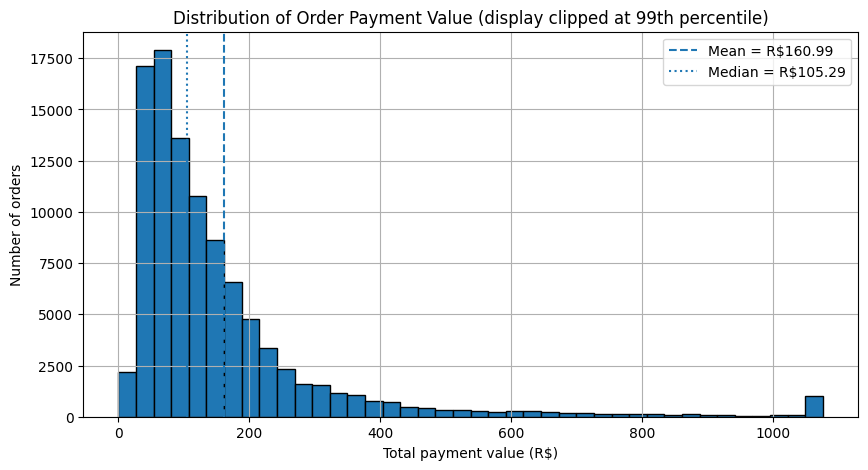

In [10]:
payment = df["total_payment_value"].dropna()
upper = payment.quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(payment.clip(upper=upper), bins=40, edgecolor="black")
plt.axvline(payment.mean(), linestyle="--", label=f"Mean = R${payment.mean():,.2f}")
plt.axvline(payment.median(), linestyle=":", label=f"Median = R${payment.median():,.2f}")
plt.title("Distribution of Order Payment Value (display clipped at 99th percentile)")
plt.xlabel("Total payment value (R$)")
plt.ylabel("Number of orders")
plt.legend()
plt.show()

### Distribution: delivery time

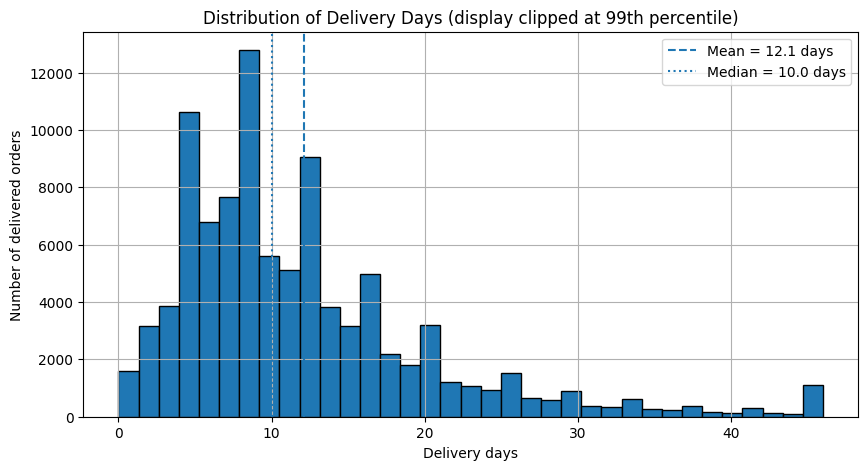

In [11]:
delivery = delivered["delivery_days"].dropna()
upper = delivery.quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(delivery.clip(upper=upper), bins=35, edgecolor="black")
plt.axvline(delivery.mean(), linestyle="--", label=f"Mean = {delivery.mean():.1f} days")
plt.axvline(delivery.median(), linestyle=":", label=f"Median = {delivery.median():.1f} days")
plt.title("Distribution of Delivery Days (display clipped at 99th percentile)")
plt.xlabel("Delivery days")
plt.ylabel("Number of delivered orders")
plt.legend()
plt.show()

### Distribution: review scores

Review scores are ordinal categories from 1 to 5, so a count chart is more informative than treating them as continuous measurements.

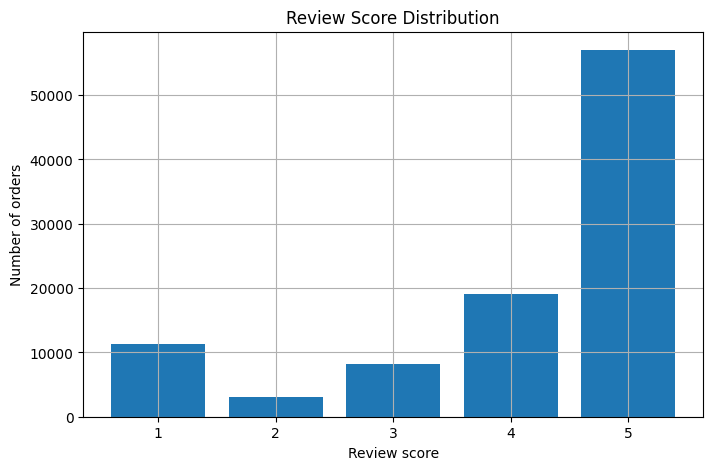

,orders
review_score,
1.0000,11363
2.0000,3131
3.0000,8133
4.0000,19038
5.0000,57008


In [12]:
review_counts = df["review_score"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(review_counts.index.astype(int).astype(str), review_counts.values)
plt.title("Review Score Distribution")
plt.xlabel("Review score")
plt.ylabel("Number of orders")
plt.show()

display(review_counts.rename("orders").to_frame())

## 7. Categorical EDA

We examine order status, payment method, and customer state. `payment_types_used` may contain combined methods because some orders used split payments.

In [13]:
for column in ["order_status", "payment_types_used", "customer_state"]:
    counts = df[column].value_counts(dropna=False).head(15)
    share = df[column].value_counts(normalize=True, dropna=False).head(15).mul(100)
    summary = pd.DataFrame({"count": counts, "percent": share})
    print(f"\nTop values for {column}")
    display(summary)


Top values for order_status


,count,percent
order_status,,
delivered,96478,97.0203
shipped,1107,1.1132
canceled,625,0.6285
unavailable,609,0.6124
invoiced,314,0.3158
processing,301,0.3027
created,5,0.0050
approved,2,0.0020



Top values for payment_types_used


,count,percent
payment_types_used,,
credit_card,74259,74.6764
boleto,19784,19.8952
"credit_card,voucher",2245,2.2576
voucher,1621,1.6301
debit_card,1527,1.5356
not_defined,3,0.0030
"credit_card,debit_card",1,0.0010
NaN,1,0.0010



Top values for customer_state


,count,percent
customer_state,,
SP,41746,41.9807
RJ,12852,12.9242
MG,11635,11.7004
RS,5466,5.4967
PR,5045,5.0734
SC,3637,3.6574
BA,3380,3.3990
DF,2140,2.1520
ES,2033,2.0444


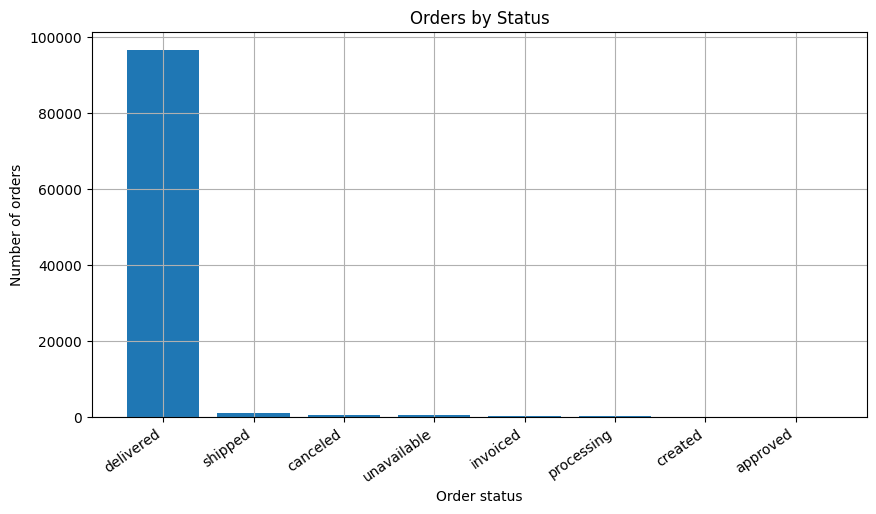

In [14]:
status_counts = df["order_status"].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(status_counts.index, status_counts.values)
plt.title("Orders by Status")
plt.xlabel("Order status")
plt.ylabel("Number of orders")
plt.xticks(rotation=35, ha="right")
plt.show()

## 8. Time-based EDA

Orders and delivered revenue are summarised by month. The earliest and latest months may be incomplete, so they should not be compared as if they contained full months.

In [15]:
df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype("string")
df["purchase_weekday"] = df["order_purchase_timestamp"].dt.day_name()
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour

monthly_orders = (
    df.dropna(subset=["purchase_month"])
      .groupby("purchase_month")
      .agg(
          orders=("order_id", "nunique"),
          customers=("customer_unique_id", "nunique"),
          payment_value=("total_payment_value", "sum"),
      )
      .reset_index()
)

display(monthly_orders.head())

,purchase_month,orders,customers,payment_value
0,2016-09,4,4,252.2400
1,2016-10,324,321,"59,090.4800"
2,2016-12,1,1,19.6200
3,2017-01,800,765,"138,488.0400"
4,2017-02,1780,1755,"291,908.0100"


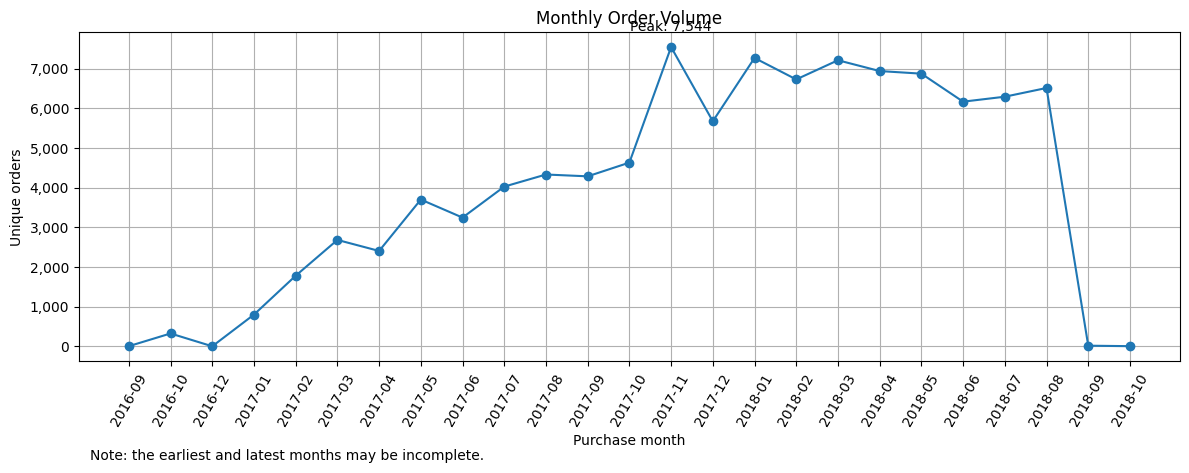

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_orders["purchase_month"], monthly_orders["orders"], marker="o")
ax.set_title("Monthly Order Volume")
ax.set_xlabel("Purchase month")
ax.set_ylabel("Unique orders")
ax.yaxis.set_major_formatter(whole_number)
ax.tick_params(axis="x", rotation=60)

peak = monthly_orders.loc[monthly_orders["orders"].idxmax()]
ax.annotate(
    f"Peak: {int(peak['orders']):,}",
    xy=(peak["purchase_month"], peak["orders"]),
    xytext=(0, 12),
    textcoords="offset points",
    ha="center",
)

ax.text(
    0.01,
    -0.30,
    "Note: the earliest and latest months may be incomplete.",
    transform=ax.transAxes,
)
fig.tight_layout()
plt.show()

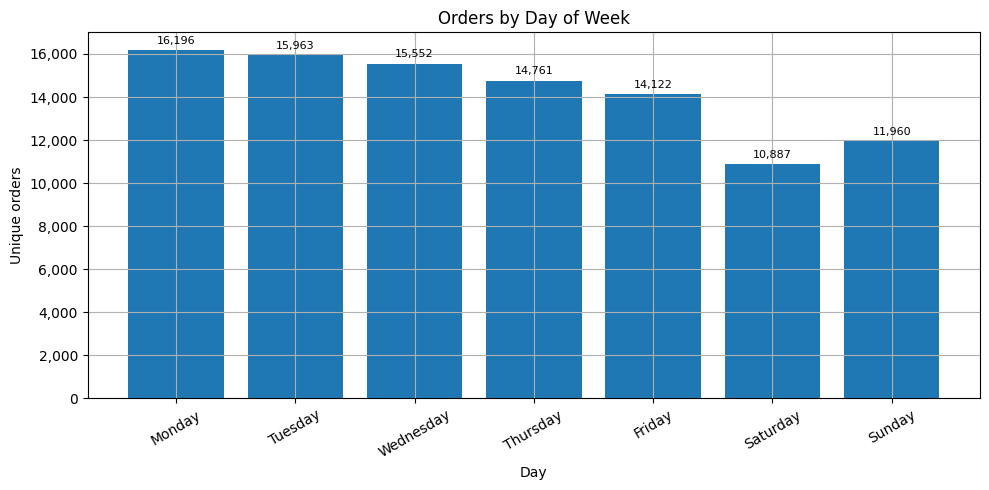

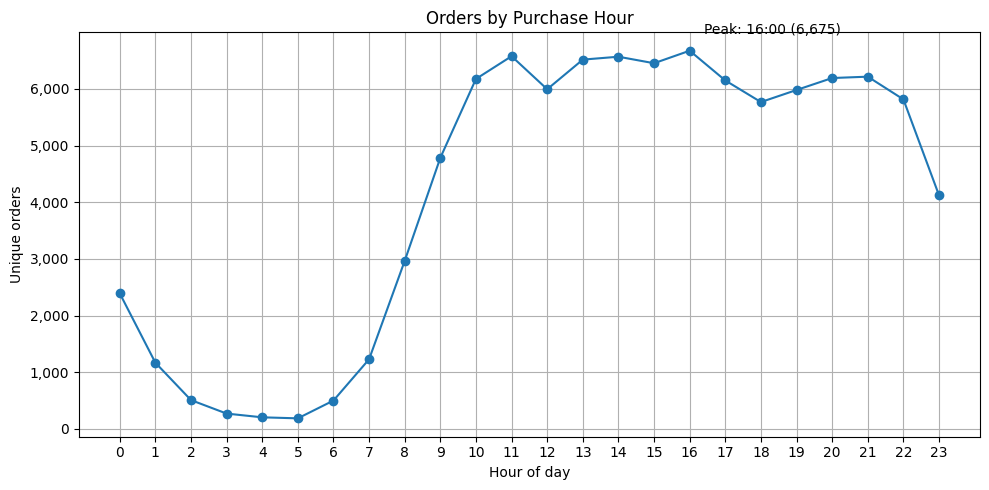

In [17]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_counts = df["purchase_weekday"].value_counts().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(weekday_counts.index, weekday_counts.values)
ax.set_title("Orders by Day of Week")
ax.set_xlabel("Day")
ax.set_ylabel("Unique orders")
ax.yaxis.set_major_formatter(whole_number)
ax.tick_params(axis="x", rotation=30)
ax.bar_label(bars, labels=[f"{int(v):,}" for v in weekday_counts.values], padding=3, fontsize=8)
fig.tight_layout()
plt.show()

hour_counts = df["purchase_hour"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hour_counts.index, hour_counts.values, marker="o")
ax.set_title("Orders by Purchase Hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Unique orders")
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(whole_number)

peak_hour = int(hour_counts.idxmax())
peak_orders = int(hour_counts.max())
ax.annotate(
    f"Peak: {peak_hour}:00 ({peak_orders:,})",
    xy=(peak_hour, peak_orders),
    xytext=(10, 12),
    textcoords="offset points",
)
fig.tight_layout()
plt.show()

## 9. Geographic EDA

The top states are compared using delivered order count, delivered payment value, and median delivery time.

In [18]:
state_summary = (
    delivered.groupby("customer_state")
    .agg(
        delivered_orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        payment_value=("total_payment_value", "sum"),
        median_delivery_days=("delivery_days", "median"),
        late_rate=("is_late", "mean"),
        median_review=("review_score", "median"),
    )
    .sort_values("payment_value", ascending=False)
)

display(state_summary.head(10))

,delivered_orders,customers,payment_value,median_delivery_days,late_rate,median_review
customer_state,,,,,,
SP,40501,39156,"5,770,266.1900",7.0000,0.0449,5.0000
RJ,12350,11917,"2,055,690.4500",12.0000,0.1211,5.0000
MG,11354,11001,"1,819,277.6100",10.0000,0.0457,5.0000
RS,5345,5168,"861,802.4000",13.0000,0.0608,5.0000
PR,4923,4769,"781,919.5500",10.0000,0.0404,5.0000
SC,3546,3449,"595,208.4000",13.0000,0.0821,5.0000
BA,3256,3158,"591,270.6000",16.0000,0.1216,5.0000
DF,2080,2019,"346,146.1700",11.0000,0.0567,5.0000
GO,1957,1895,"334,294.2200",13.0000,0.0654,5.0000


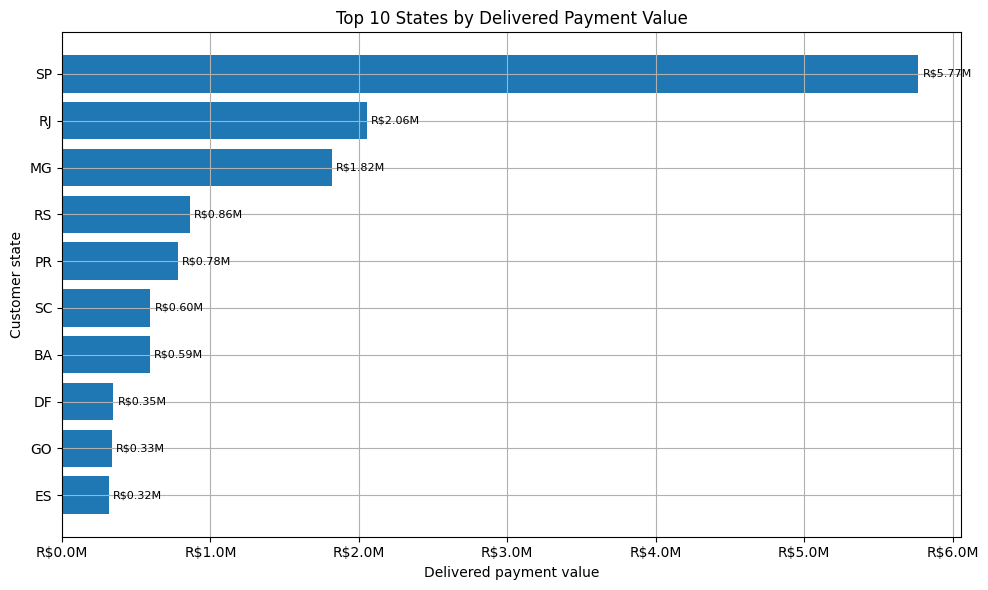

In [19]:
top_states = state_summary.head(10).sort_values("payment_value")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_states.index, top_states["payment_value"])
ax.set_title("Top 10 States by Delivered Payment Value")
ax.set_xlabel("Delivered payment value")
ax.set_ylabel("Customer state")
ax.xaxis.set_major_formatter(currency_millions)
ax.bar_label(
    bars,
    labels=[f"R${value / 1_000_000:.2f}M" for value in top_states["payment_value"]],
    padding=3,
    fontsize=8,
)
fig.tight_layout()
plt.show()

# PART 2 - STATISTICAL ANALYSIS

## 10. Prepare the statistical analysis sample

Delivery-related tests use delivered orders with non-missing delivery time, review score, and lateness. We also create `low_review`, where scores 1-2 are treated as negative reviews.

In [20]:
analysis_df = df[
    df["order_status"].eq("delivered")
    & df["delivery_days"].notna()
    & df["review_score"].notna()
    & df["is_late"].notna()
].copy()

analysis_df["low_review"] = (analysis_df["review_score"] <= 2).astype(int)
analysis_df["delivery_group"] = np.where(analysis_df["is_late"], "Late", "On time")

print(f"Statistical analysis sample: {len(analysis_df):,} delivered orders")
print("Low review means review_score <= 2.")
display(
    analysis_df.groupby("delivery_group")
    .agg(
        orders=("order_id", "size"),
        mean_review=("review_score", "mean"),
        median_review=("review_score", "median"),
        low_review_rate=("low_review", "mean"),
        median_delivery_days=("delivery_days", "median"),
    )
)

Statistical analysis sample: 95,824 delivered orders
Low review means review_score <= 2.


,orders,mean_review,median_review,low_review_rate,median_delivery_days
delivery_group,,,,,
Late,6381,2.2705,1.0000,0.6242,31.0000
On time,89443,4.2904,5.0000,0.0927,9.0000


## 11. Does slower delivery relate to lower review scores? - Spearman correlation

### Hypotheses

- **Null hypothesis (H0):** There is no monotonic association between delivery time and review score.
- **Alternative hypothesis (H1):** Delivery time and review score are associated.

### Why Spearman instead of Pearson?

`review_score` is an ordinal 1-to-5 rating, and `delivery_days` is skewed. Spearman correlation uses ranks and is therefore appropriate for this combination.

In [21]:
def p_value_text(p):
    return "< 1e-300" if p == 0 else f"{p:.3e}"

rho_delivery, p_delivery = spearmanr(
    analysis_df["delivery_days"],
    analysis_df["review_score"],
    nan_policy="omit",
)

rho_delay, p_delay = spearmanr(
    analysis_df["delay_days"],
    analysis_df["review_score"],
    nan_policy="omit",
)

correlation_results = pd.DataFrame({
    "relationship": [
        "delivery_days vs review_score",
        "delay_days vs review_score",
    ],
    "spearman_rho": [rho_delivery, rho_delay],
    "p_value": [p_delivery, p_delay],
})

display(correlation_results)
print(f"Delivery days: Spearman rho = {rho_delivery:.3f}, p {p_value_text(p_delivery)}")
print(f"Delay days: Spearman rho = {rho_delay:.3f}, p {p_value_text(p_delay)}")

if rho_delivery < 0 and p_delivery < 0.05:
    print("Conclusion: Slower delivery is significantly associated with lower review scores.")
else:
    print("Conclusion: The data does not show a significant negative association.")

print("This is an association, not proof that delivery time alone caused the review score.")

,relationship,spearman_rho,p_value
0,delivery_days vs review_score,-0.2346,0.0000
1,delay_days vs review_score,-0.1764,0.0000


Delivery days: Spearman rho = -0.235, p < 1e-300
Delay days: Spearman rho = -0.176, p < 1e-300
Conclusion: Slower delivery is significantly associated with lower review scores.
This is an association, not proof that delivery time alone caused the review score.


,count,mean,median
review_score,,,
1.0000,9351,20.8597,16.0000
2.0000,2921,16.1777,13.0000
3.0000,7916,13.7899,12.0000
4.0000,18888,11.8416,10.0000
5.0000,56748,10.2163,9.0000


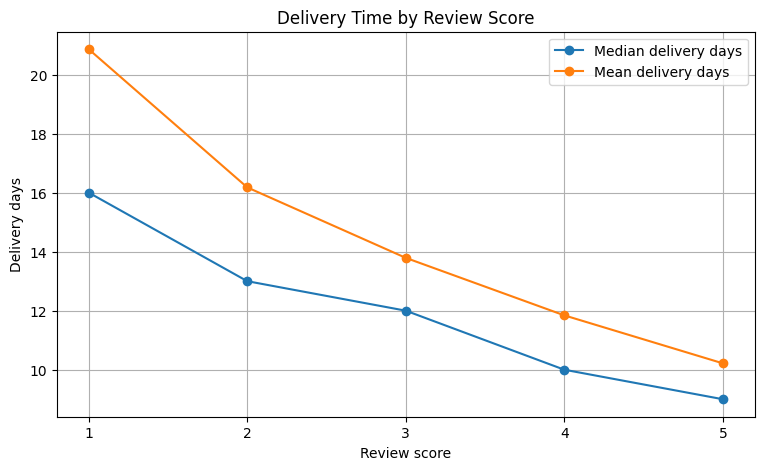

In [22]:
review_by_days = (
    analysis_df.groupby("review_score")["delivery_days"]
    .agg(["count", "mean", "median"])
)
display(review_by_days)

plt.figure(figsize=(9, 5))
plt.plot(review_by_days.index, review_by_days["median"], marker="o", label="Median delivery days")
plt.plot(review_by_days.index, review_by_days["mean"], marker="o", label="Mean delivery days")
plt.title("Delivery Time by Review Score")
plt.xlabel("Review score")
plt.ylabel("Delivery days")
plt.xticks([1, 2, 3, 4, 5])
plt.legend()
plt.show()

## 12. Do late and on-time orders have different review scores? - Mann-Whitney U

Review scores are ordinal and heavily concentrated at 5, so a t-test is not the best choice. Mann-Whitney U compares the rank distributions of the two independent groups.

- **H0:** Late and on-time orders have the same review-score distribution.
- **H1:** Their review-score distributions differ.

In [23]:
late_reviews = analysis_df.loc[analysis_df["is_late"], "review_score"]
ontime_reviews = analysis_df.loc[~analysis_df["is_late"], "review_score"]

u_stat, p_mann = mannwhitneyu(
    late_reviews,
    ontime_reviews,
    alternative="two-sided",
)

# Rank-biserial correlation ranges from -1 to +1.
# Negative here means the first group (late) tends to have lower scores.
rank_biserial = (2 * u_stat) / (len(late_reviews) * len(ontime_reviews)) - 1

mann_summary = pd.DataFrame({
    "group": ["Late", "On time"],
    "n": [len(late_reviews), len(ontime_reviews)],
    "mean_review": [late_reviews.mean(), ontime_reviews.mean()],
    "median_review": [late_reviews.median(), ontime_reviews.median()],
})

display(mann_summary)
print(f"Mann-Whitney U = {u_stat:,.0f}")
print(f"p-value {p_value_text(p_mann)}")
print(f"Rank-biserial effect size = {rank_biserial:.3f}")

if p_mann < 0.05:
    print("Reject H0: review-score distributions differ between late and on-time orders.")
else:
    print("Fail to reject H0: insufficient evidence of a difference.")

,group,n,mean_review,median_review
0,Late,6381,2.2705,1.0000
1,On time,89443,4.2904,5.0000


Mann-Whitney U = 103,305,546
p-value < 1e-300
Rank-biserial effect size = -0.638
Reject H0: review-score distributions differ between late and on-time orders.


## 13. Is late delivery linked to a low review? - Chi-Square test

Both variables are categorical:

- `is_late`: late / on time
- `low_review`: score 1-2 / score 3-5

Therefore, the Chi-Square test of independence is appropriate.

- **H0:** Lateness and low-review status are independent.
- **H1:** They are associated.

In [24]:
contingency = pd.crosstab(
    analysis_df["delivery_group"],
    analysis_df["low_review"],
).rename(columns={0: "Review 3-5", 1: "Review 1-2"})

display(contingency)

chi2_stat, p_chi, dof, expected = chi2_contingency(contingency)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

n_total = contingency.to_numpy().sum()
cramers_v = math.sqrt(
    chi2_stat / (n_total * min(contingency.shape[0] - 1, contingency.shape[1] - 1))
)

print(f"Chi-Square = {chi2_stat:,.3f}")
print(f"Degrees of freedom = {dof}")
print(f"p-value {p_value_text(p_chi)}")
print(f"Minimum expected cell count = {expected_df.min().min():,.1f}")
print(f"Cramer's V effect size = {cramers_v:.3f}")

if p_chi < 0.05:
    print("Reject H0: late delivery and low reviews are statistically associated.")
else:
    print("Fail to reject H0: insufficient evidence of an association.")

low_review,Review 3-5,Review 1-2
delivery_group,,
Late,2398,3983
On time,81154,8289


Chi-Square = 15,064.149
Degrees of freedom = 1
p-value < 1e-300
Minimum expected cell count = 817.2
Cramer's V effect size = 0.396
Reject H0: late delivery and low reviews are statistically associated.


## 14. Confidence intervals and effect size

A p-value says whether the pattern is unlikely to be random under the null hypothesis. It does not show the practical size. We therefore report:

- Wilson 95% confidence intervals for low-review rates
- Absolute percentage-point difference
- Relative risk
- Cohen's h for the difference between two proportions

In [25]:
rate_rows = []
for group_name, group_data in analysis_df.groupby("delivery_group"):
    count_low = int(group_data["low_review"].sum())
    n_group = len(group_data)
    rate = count_low / n_group
    lo, hi = proportion_confint(count=count_low, nobs=n_group, method="wilson")
    rate_rows.append({
        "group": group_name,
        "low_reviews": count_low,
        "orders": n_group,
        "low_review_rate": rate,
        "ci_95_lower": lo,
        "ci_95_upper": hi,
    })

rate_ci = pd.DataFrame(rate_rows).set_index("group")
display(rate_ci)

late_rate = rate_ci.loc["Late", "low_review_rate"]
ontime_rate = rate_ci.loc["On time", "low_review_rate"]
absolute_difference = late_rate - ontime_rate
relative_risk = late_rate / ontime_rate
cohens_h = proportion_effectsize(late_rate, ontime_rate)

print(f"Absolute difference = {absolute_difference:.2%} ({absolute_difference*100:.2f} percentage points)")
print(f"Relative risk = {relative_risk:.2f} times")
print(f"Cohen's h = {cohens_h:.3f}")

if abs(cohens_h) < 0.2:
    effect_label = "negligible"
elif abs(cohens_h) < 0.5:
    effect_label = "small"
elif abs(cohens_h) < 0.8:
    effect_label = "medium"
else:
    effect_label = "large"
print(f"Practical interpretation: the proportion effect is {effect_label} by common Cohen's h guidelines.")

,low_reviews,orders,low_review_rate,ci_95_lower,ci_95_upper
group,,,,,
Late,3983,6381,0.6242,0.6122,0.6360
On time,8289,89443,0.0927,0.0908,0.0946


Absolute difference = 53.15% (53.15 percentage points)
Relative risk = 6.74 times
Cohen's h = 1.203
Practical interpretation: the proportion effect is large by common Cohen's h guidelines.


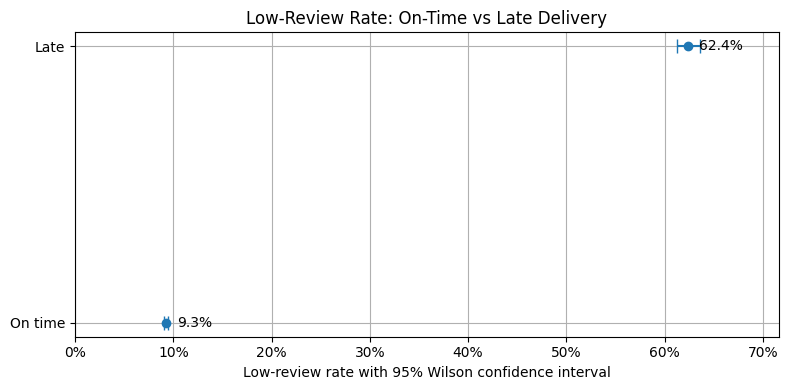

In [26]:
plot_ci = rate_ci.loc[["On time", "Late"]].copy()
y = np.arange(len(plot_ci))
centres = plot_ci["low_review_rate"].to_numpy()
errors = np.vstack([
    centres - plot_ci["ci_95_lower"].to_numpy(),
    plot_ci["ci_95_upper"].to_numpy() - centres,
])

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(centres, y, xerr=errors, fmt="o", capsize=5)
ax.set_yticks(y, plot_ci.index)
ax.set_xlabel("Low-review rate with 95% Wilson confidence interval")
ax.set_title("Low-Review Rate: On-Time vs Late Delivery")
ax.set_xlim(0, min(1, plot_ci["ci_95_upper"].max() + 0.08))
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

for row_index, value in enumerate(centres):
    ax.annotate(
        f"{value:.1%}",
        xy=(value, row_index),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
    )

fig.tight_layout()
plt.show()

## 15. Confidence interval for the overall late-delivery rate

This interval communicates uncertainty around the late-delivery percentage rather than presenting a falsely exact single value.

In [27]:
late_count = int(analysis_df["is_late"].sum())
late_n = len(analysis_df)
late_lo, late_hi = proportion_confint(late_count, late_n, method="wilson")

print(f"Late-delivery rate = {late_count / late_n:.2%}")
print(f"95% Wilson CI = [{late_lo:.2%}, {late_hi:.2%}]")

Late-delivery rate = 6.66%
95% Wilson CI = [6.50%, 6.82%]


## 16. Statistical power

To avoid using the very large observed effect as the planning target, this section asks a practical question: how many orders per group would be needed to detect a **3 percentage-point increase** over the on-time low-review rate with 80% power and 5% significance?

In [28]:
baseline_rate = ontime_rate
target_rate = min(baseline_rate + 0.03, 0.999)
planned_effect = proportion_effectsize(target_rate, baseline_rate)

power_analysis = NormalIndPower()
required_per_group = power_analysis.solve_power(
    effect_size=planned_effect,
    alpha=0.05,
    power=0.80,
    ratio=1,
    alternative="two-sided",
)

print(f"Baseline low-review rate: {baseline_rate:.2%}")
print(f"Target rate to detect: {target_rate:.2%}")
print(f"Required sample size: approximately {math.ceil(required_per_group):,} orders per group")
print(f"Available late orders: {len(late_reviews):,}")
print(f"Available on-time orders: {len(ontime_reviews):,}")

if len(late_reviews) >= required_per_group and len(ontime_reviews) >= required_per_group:
    print("The available sample is large enough for this planned difference.")
else:
    print("At least one group is too small for this planned difference.")

Baseline low-review rate: 9.27%
Target rate to detect: 12.27%
Required sample size: approximately 1,669 orders per group
Available late orders: 6,381
Available on-time orders: 89,443
The available sample is large enough for this planned difference.


## 17. Multiple testing example with FDR correction

Testing many states separately increases the chance of false positives. For the ten states with the most analysed orders, we test whether late delivery is associated with low reviews and adjust p-values using Benjamini-Hochberg False Discovery Rate (FDR).

This is included to demonstrate the handbook's warning about many tests. State-level findings should still be interpreted cautiously because operational differences may confound the relationship.

In [29]:
top_state_names = analysis_df["customer_state"].value_counts().head(10).index
state_test_rows = []

for state in top_state_names:
    state_data = analysis_df[analysis_df["customer_state"].eq(state)]
    table = pd.crosstab(state_data["is_late"], state_data["low_review"])

    if table.shape != (2, 2):
        continue

    chi2_s, p_s, dof_s, expected_s = chi2_contingency(table)
    n_s = table.to_numpy().sum()
    v_s = math.sqrt(chi2_s / n_s)  # 2x2 table

    state_test_rows.append({
        "state": state,
        "orders": n_s,
        "chi_square": chi2_s,
        "raw_p_value": p_s,
        "cramers_v": v_s,
        "min_expected_count": np.min(expected_s),
    })

state_tests = pd.DataFrame(state_test_rows)

if not state_tests.empty:
    reject, adjusted, _, _ = multipletests(
        state_tests["raw_p_value"],
        alpha=0.05,
        method="fdr_bh",
    )
    state_tests["fdr_adjusted_p"] = adjusted
    state_tests["significant_after_fdr"] = reject
    state_tests = state_tests.sort_values("fdr_adjusted_p")

display(state_tests)

,state,orders,chi_square,raw_p_value,cramers_v,min_expected_count,fdr_adjusted_p,significant_after_fdr
0,SP,40266,"3,731.3004",0.0000,0.3044,190.8597,0.0000,True
1,RJ,12211,"3,306.1998",0.0000,0.5203,266.8519,0.0000,True
2,MG,11285,"1,133.9137",0.0000,0.3170,59.3381,0.0000,True
3,RS,5326,882.8254,0.0000,0.4071,38.2717,0.0000,True
5,SC,3519,596.1400,0.0000,0.4116,36.8821,0.0000,True
6,BA,3229,571.6958,0.0000,0.4208,65.2883,0.0000,True
7,DF,2070,371.2677,0.0000,0.4235,15.6193,0.0000,True
4,PR,4900,349.0104,0.0000,0.2669,21.1024,0.0000,True
8,ES,1969,339.6703,0.0000,0.4153,28.3189,0.0000,True
9,GO,1946,291.5673,0.0000,0.3871,16.3124,0.0000,True


# PART 3 - CUSTOMER AND REVENUE ANALYSIS

## 18. RFM segmentation

RFM measures:

- **Recency:** days since the customer's most recent delivered purchase
- **Frequency:** number of distinct delivered orders
- **Monetary:** total delivered payment value

The handbook warns that most Olist customers buy once. Therefore, frequency scoring uses simple actual-order bands instead of forcing tied one-time buyers into artificial quintiles.

In [30]:
rfm_source = df[
    df["order_status"].eq("delivered")
    & df["customer_unique_id"].notna()
    & df["order_purchase_timestamp"].notna()
    & df["total_payment_value"].notna()
].copy()

snapshot_date = rfm_source["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    rfm_source.groupby("customer_unique_id")
    .agg(
        recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("total_payment_value", "sum"),
    )
    .reset_index()
)

# Quintiles for recency and monetary. rank(method='first') avoids duplicate qcut edges.
rfm["R_score"] = pd.qcut(
    rfm["recency"].rank(method="first"),
    q=5,
    labels=[5, 4, 3, 2, 1],
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
).astype(int)

# Honest frequency scoring because approximately 97% of customers order only once.
rfm["F_score"] = np.select(
    [rfm["frequency"].eq(1), rfm["frequency"].eq(2), rfm["frequency"].ge(3)],
    [1, 3, 5],
    default=1,
).astype(int)

conditions = [
    (rfm["R_score"] >= 4) & (rfm["F_score"] >= 3) & (rfm["M_score"] >= 4),
    (rfm["F_score"] >= 3) & (rfm["M_score"] >= 3),
    (rfm["R_score"] >= 4) & (rfm["M_score"] >= 4),
    (rfm["R_score"] >= 4),
    (rfm["R_score"] <= 2) & (rfm["M_score"] >= 4),
    (rfm["M_score"] == 5),
]

segments = [
    "Champions",
    "Loyal",
    "High-value recent",
    "Recent",
    "At risk",
    "Big spenders",
]

rfm["segment"] = np.select(conditions, segments, default="Regular")

single_order_share = rfm["frequency"].eq(1).mean()
print(f"Customers with exactly one delivered order: {single_order_share:.2%}")
display(rfm.head())

Customers with exactly one delivered order: 97.00%


,customer_unique_id,recency,frequency,monetary,R_score,M_score,F_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.9000,4,4,1,High-value recent
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.1900,4,1,1,Recent
2,0000f46a3911fa3c0805444483337064,537,1,86.2200,1,2,1,Regular
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.6200,2,1,1,Regular
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.8900,2,4,1,At risk


In [31]:
segment_summary = (
    rfm.groupby("segment")
    .agg(
        customers=("customer_unique_id", "size"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_revenue=("monetary", "sum"),
    )
    .sort_values("total_revenue", ascending=False)
)

segment_summary["customer_share"] = segment_summary["customers"] / segment_summary["customers"].sum()
segment_summary["revenue_share"] = segment_summary["total_revenue"] / segment_summary["total_revenue"].sum()
display(segment_summary)

,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,customer_share,revenue_share
segment,,,,,,,
High-value recent,14405,91.3593,1.0000,302.1923,"4,353,079.9100",0.1543,0.2823
At risk,13778,393.7937,1.0000,307.7529,"4,240,219.2300",0.1476,0.2749
Regular,37528,325.9824,1.0030,81.6002,"3,062,292.9000",0.4020,0.1986
Recent,21805,89.7695,1.0034,72.9178,"1,589,973.2700",0.2336,0.1031
Big spenders,3222,220.0053,1.0000,411.2910,"1,325,179.6100",0.0345,0.0859
Loyal,1630,296.8245,2.0834,296.9128,"483,967.8800",0.0175,0.0314
Champions,989,88.7381,2.1810,371.8392,"367,748.9700",0.0106,0.0238


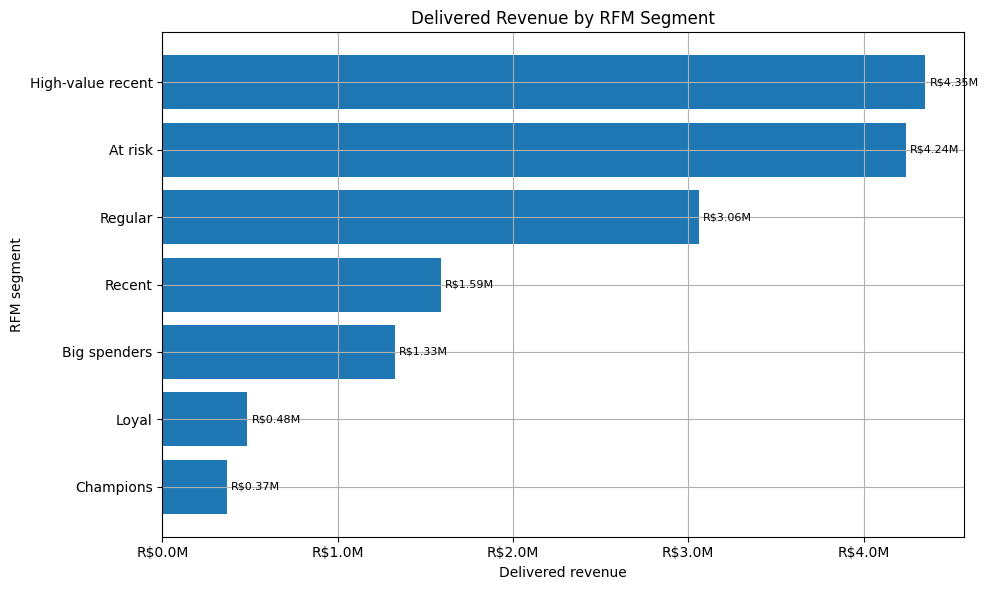

In [32]:
segment_plot = segment_summary.sort_values("total_revenue")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(segment_plot.index, segment_plot["total_revenue"])
ax.set_title("Delivered Revenue by RFM Segment")
ax.set_xlabel("Delivered revenue")
ax.set_ylabel("RFM segment")
ax.xaxis.set_major_formatter(currency_millions)
ax.bar_label(
    bars,
    labels=[f"R${value / 1_000_000:.2f}M" for value in segment_plot["total_revenue"]],
    padding=3,
    fontsize=8,
)
fig.tight_layout()
plt.show()

## 19. Pareto analysis

The handbook demonstrates seller-level Pareto analysis. This supplied master file does **not** contain `seller_id` or product-category columns, so seller/category concentration cannot be calculated exactly from this file. The same Pareto method is applied to **customer revenue concentration**, which answers what share of revenue is generated by the highest-value customers.

In [33]:
customer_revenue = rfm.set_index("customer_unique_id")["monetary"].sort_values(ascending=False)
cumulative_revenue_share = customer_revenue.cumsum() / customer_revenue.sum()
cumulative_customer_share = np.arange(1, len(customer_revenue) + 1) / len(customer_revenue)

number_top_20 = max(1, math.ceil(0.20 * len(customer_revenue)))
top_20_share = customer_revenue.iloc[:number_top_20].sum() / customer_revenue.sum()
customers_needed_for_80 = (
    np.searchsorted(cumulative_revenue_share.to_numpy(), 0.80) + 1
) / len(customer_revenue)

print(f"Top 20% of customers generate {top_20_share:.2%} of delivered revenue.")
print(f"Approximately {customers_needed_for_80:.2%} of customers generate 80% of delivered revenue.")

Top 20% of customers generate 53.53% of delivered revenue.
Approximately 48.85% of customers generate 80% of delivered revenue.


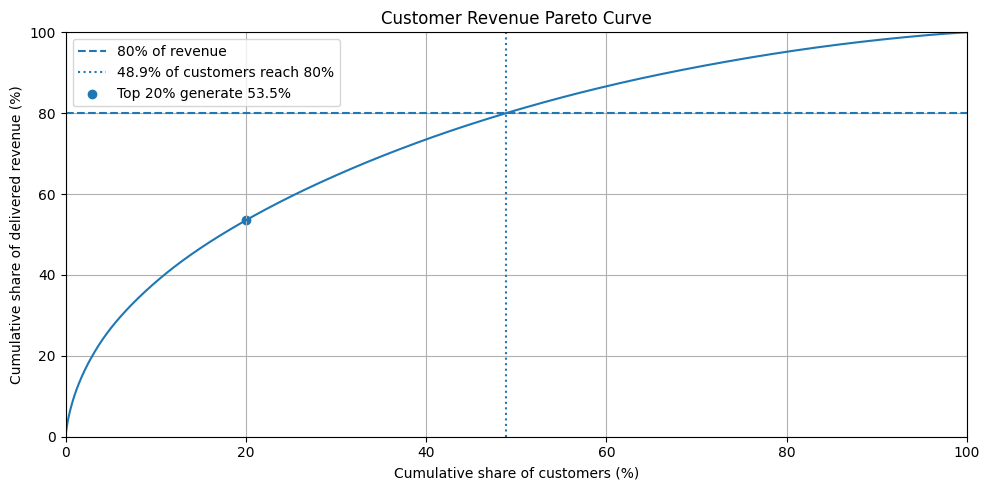

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cumulative_customer_share * 100, cumulative_revenue_share * 100)
ax.axhline(80, linestyle="--", label="80% of revenue")
ax.axvline(
    customers_needed_for_80 * 100,
    linestyle=":",
    label=f"{customers_needed_for_80:.1%} of customers reach 80%",
)
ax.scatter(
    [20],
    [top_20_share * 100],
    label=f"Top 20% generate {top_20_share:.1%}",
)
ax.set_title("Customer Revenue Pareto Curve")
ax.set_xlabel("Cumulative share of customers (%)")
ax.set_ylabel("Cumulative share of delivered revenue (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend()
fig.tight_layout()
plt.show()

# PART 4 - FINAL INTERPRETATION AND EXPORT

## 20. Automated findings summary

The following cell converts the main statistics into submission-ready statements. Use these findings together with the displayed tables and charts, and avoid claiming causation.

In [35]:
print("E-COMMERCE EDA AND STATISTICS - KEY FINDINGS")
print("=" * 60)
print(f"1. The dataset contains {len(df):,} unique order-level rows and {df['customer_unique_id'].nunique():,} unique customers.")
print(f"2. Recorded payment value across all statuses is R${df['total_payment_value'].sum():,.2f}; delivered orders account for R${delivered['total_payment_value'].sum():,.2f}.")
print(f"3. Payment value is right-skewed: mean R${payment.mean():,.2f} versus median R${payment.median():,.2f}.")
print(f"4. The analysed delivered-order late rate is {late_count/late_n:.2%}, with 95% CI [{late_lo:.2%}, {late_hi:.2%}].")
print(f"5. Delivery days and review score have a negative Spearman association (rho={rho_delivery:.3f}, p {p_value_text(p_delivery)}).")
print(f"6. Low-review rate is {late_rate:.2%} for late orders versus {ontime_rate:.2%} for on-time orders, a difference of {absolute_difference*100:.2f} percentage points.")
print(f"7. The late-vs-low-review association is statistically significant (Chi-Square={chi2_stat:,.1f}, Cramer's V={cramers_v:.3f}).")
print(f"8. The Mann-Whitney effect is large in direction (rank-biserial={rank_biserial:.3f}); late orders tend to receive lower reviews.")
print(f"9. {single_order_share:.2%} of customers have only one delivered order, so Frequency provides limited separation in Olist RFM analysis.")
print(f"10. The top 20% of customers generate {top_20_share:.2%} of delivered revenue.")
print("\nBusiness interpretation: delivery reliability is strongly connected with customer satisfaction. Prioritise late-order prevention, proactive communication, and recovery actions for delayed orders. Because this is observational data, the results show association rather than proof of causation.")

E-COMMERCE EDA AND STATISTICS - KEY FINDINGS
1. The dataset contains 99,441 unique order-level rows and 96,096 unique customers.
2. Recorded payment value across all statuses is R$16,008,872.12; delivered orders account for R$15,422,461.77.
3. Payment value is right-skewed: mean R$160.99 versus median R$105.29.
4. The analysed delivered-order late rate is 6.66%, with 95% CI [6.50%, 6.82%].
5. Delivery days and review score have a negative Spearman association (rho=-0.235, p < 1e-300).
6. Low-review rate is 62.42% for late orders versus 9.27% for on-time orders, a difference of 53.15 percentage points.
7. The late-vs-low-review association is statistically significant (Chi-Square=15,064.1, Cramer's V=0.396).
8. The Mann-Whitney effect is large in direction (rank-biserial=-0.638); late orders tend to receive lower reviews.
9. 97.00% of customers have only one delivered order, so Frequency provides limited separation in Olist RFM analysis.
10. The top 20% of customers generate 53.53% of d

## Final conclusion

The final analysis uses the complete **99,441-order** Olist master dataset, representing **96,096 unique customers**. Recorded payment value across all order statuses is **R$16,008,872.12**, of which delivered orders contribute **R$15,422,461.77**. Order values are strongly right-skewed: the mean payment is **R$160.99**, while the median is **R$105.29**.

Delivery performance has a clear and practically important relationship with customer satisfaction. Among the delivered orders used for statistical analysis, **6.66%** were late (95% Wilson CI: **6.50%-6.82%**). The low-review rate was **62.42%** for late orders compared with **9.27%** for on-time orders, an absolute difference of **53.15 percentage points** and a relative risk of approximately **6.74 times**. The chi-square result was statistically significant, with **Cramer's V = 0.396**, and the Mann-Whitney comparison produced a large directional effect (**rank-biserial = -0.638**). Spearman correlation also showed that longer delivery time is associated with lower review scores (**rho = -0.235**).

Customer purchasing frequency is limited because **97.00%** of delivered customers placed only one order, so recency and monetary value are more useful than frequency for this Olist RFM segmentation. The top **20%** of customers generated **53.53%** of delivered revenue, showing moderate revenue concentration rather than a strict 80/20 pattern.

**Business recommendation:** prioritise prevention of late deliveries, proactive delay communication and targeted service recovery for delayed orders. These findings demonstrate strong association in observational data; they do not prove that delay alone caused a poor review.

## 21. Save result tables

The files are written to the current Colab session. To download one in Colab, uncomment the final two lines and change the filename as needed.

In [36]:
quality.to_csv("ecommerce_data_quality_summary.csv")
shape_summary.to_csv("ecommerce_numeric_shape_summary.csv")
state_summary.to_csv("ecommerce_state_summary.csv")
rate_ci.to_csv("ecommerce_low_review_confidence_intervals.csv")
rfm.to_csv("ecommerce_rfm_customer_segments.csv", index=False)
segment_summary.to_csv("ecommerce_rfm_segment_summary.csv")
state_tests.to_csv("ecommerce_state_tests_fdr.csv", index=False)

key_results = pd.DataFrame({
    "metric": [
        "spearman_delivery_review",
        "spearman_delivery_review_p",
        "mann_whitney_p",
        "rank_biserial_effect",
        "chi_square_late_low_review",
        "chi_square_p",
        "cramers_v",
        "late_low_review_rate",
        "ontime_low_review_rate",
        "absolute_rate_difference",
        "cohens_h",
        "top_20_customer_revenue_share",
    ],
    "value": [
        rho_delivery,
        p_delivery,
        p_mann,
        rank_biserial,
        chi2_stat,
        p_chi,
        cramers_v,
        late_rate,
        ontime_rate,
        absolute_difference,
        cohens_h,
        top_20_share,
    ],
})
key_results.to_csv("ecommerce_key_statistical_results.csv", index=False)

print("Saved output files:")
for filename in [
    "ecommerce_data_quality_summary.csv",
    "ecommerce_numeric_shape_summary.csv",
    "ecommerce_state_summary.csv",
    "ecommerce_low_review_confidence_intervals.csv",
    "ecommerce_rfm_customer_segments.csv",
    "ecommerce_rfm_segment_summary.csv",
    "ecommerce_state_tests_fdr.csv",
    "ecommerce_key_statistical_results.csv",
]:
    print("-", filename)

# Google Colab download example:
# from google.colab import files
# files.download("ecommerce_key_statistical_results.csv")

Saved output files:
- ecommerce_data_quality_summary.csv
- ecommerce_numeric_shape_summary.csv
- ecommerce_state_summary.csv
- ecommerce_low_review_confidence_intervals.csv
- ecommerce_rfm_customer_segments.csv
- ecommerce_rfm_segment_summary.csv
- ecommerce_state_tests_fdr.csv
- ecommerce_key_statistical_results.csv


## 22. Mistakes avoided

- Verified one row per order before counting revenue.
- Did not treat order IDs, postal codes, or star ratings as ordinary continuous measurements.
- Reported median alongside mean for skewed monetary data.
- Used Spearman for ordinal/skewed variables.
- Used Mann-Whitney instead of forcing a t-test on review scores.
- Reported effect sizes and confidence intervals, not only p-values.
- Applied FDR correction when repeating state-level tests.
- Restricted delivery tests to delivered orders with valid fields.
- Did not interpret correlation as causation.
- Did not force one-time customers into misleading frequency quintiles.

## Submission integrity checklist

Before submitting:

- Run **Runtime -> Run all** in Colab.
- Confirm the load cell prints `99,441` rows and `99,441` unique orders.
- Keep `master_cleaned.csv` with the notebook, or include the raw-table rebuild function.
- Confirm the final conclusion displays actual values and no placeholder text remains.
- Export or commit the key result tables generated in the last section.